## Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/stores_sales.csv")

## EDA

In [3]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,9963,CA-2015-168088,3/19/2015,3/22/2015,First Class,CM-12655,Corinna Mitchell,Home Office,United States,Houston,...,77041,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,383.4656,4,0.32,-67.6704
2117,9965,CA-2016-146374,12/5/2016,12/10/2016,Second Class,HE-14800,Harold Engle,Corporate,United States,Newark,...,19711,East,FUR-FU-10002671,Furniture,Furnishings,Electrix 20W Halogen Replacement Bulb for Zoom...,13.4000,1,0.00,6.4320
2118,9981,US-2015-151435,9/6/2015,9/9/2015,Second Class,SW-20455,Shaun Weien,Consumer,United States,Lafayette,...,70506,South,FUR-TA-10001039,Furniture,Tables,KI Adjustable-Height Table,85.9800,1,0.00,22.3548
2119,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")

<Axes: >

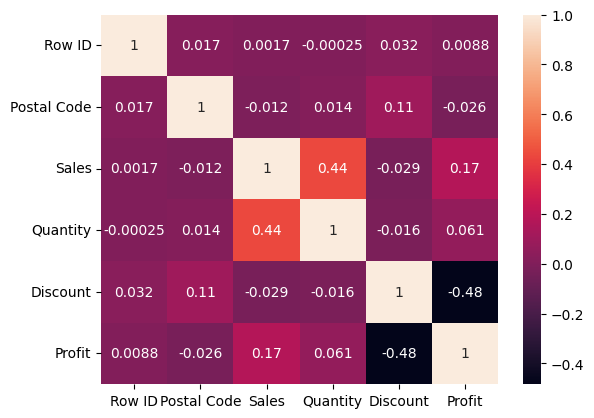

In [6]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

#### Quantity and Sales correlates well as to be expected.
#### Discount seems to have a major negative correlation with profits. 
#### Too much or too frequent discounts?

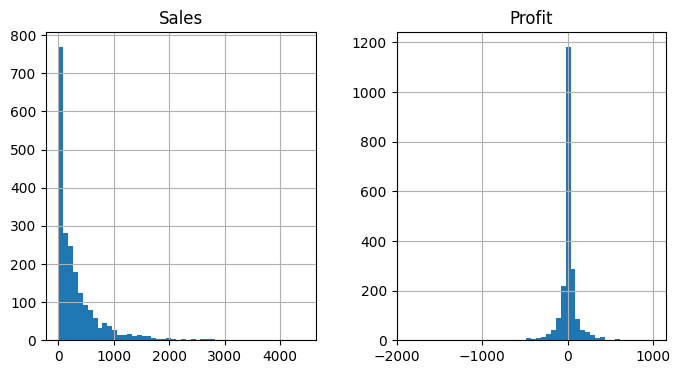

In [7]:
df[["Sales", "Profit"]].hist(bins=50, figsize=(8,4));

Sales is right-skewed as expected since sales can't be negative and later needs log for training. Profits seems kinda normal distributed.

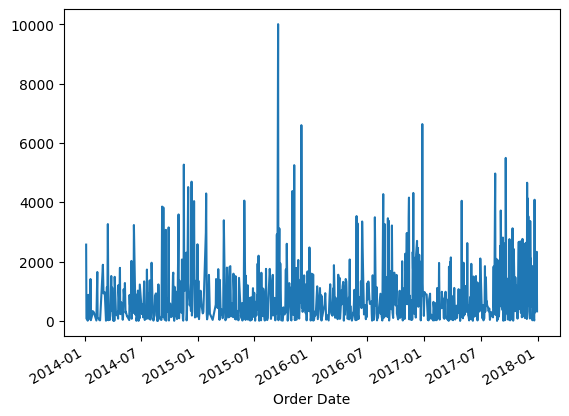

In [8]:
df.groupby("Order Date")["Sales"].sum().plot();

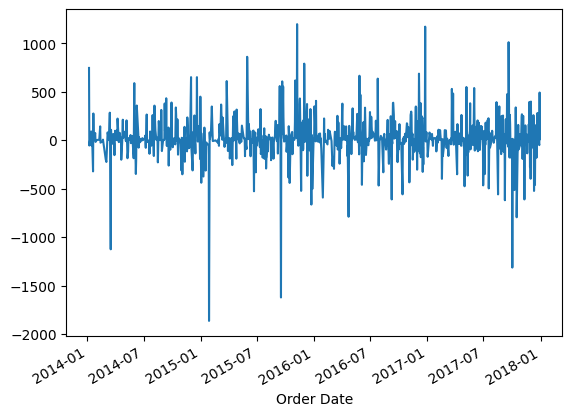

In [9]:
df.groupby("Order Date")["Profit"].sum().plot();

In [10]:
print("Discount Rates:", (df["Discount"].sort_values().unique() * 100))

Discount Rates: [ 0. 10. 15. 20. 30. 32. 40. 45. 50. 60. 70.]


In [11]:
low_profit_dates = df.nsmallest(5, "Profit")[["Order Date", "Profit", "Discount"]]
print(low_profit_dates)

     Order Date     Profit  Discount
2044 2015-01-28 -1862.3124       0.4
7    2015-09-17 -1665.0522       0.5
1108 2017-10-02 -1002.7836       0.4
1909 2017-10-16  -968.8833       0.4
100  2016-04-22  -814.4832       0.5


In [12]:
dates = low_profit_dates["Order Date"]
df.loc[df["Order Date"].isin(dates), ["Order Date","Region","Sales","Profit","Discount"]]


,Order Date,Region,Sales,Profit,Discount
7,2015-09-17,East,3083.430,-1665.0522,0.5
8,2015-09-17,East,124.200,15.5250,0.2
99,2016-04-22,West,23.560,7.0680,0.2
100,2016-04-22,West,1272.630,-814.4832,0.5
159,2017-10-02,Central,157.740,56.7864,0.0
216,2016-04-22,Central,86.620,8.6620,0.0
335,2017-10-16,East,547.300,175.1360,0.0
345,2015-09-17,Central,21.936,-10.4196,0.6
395,2016-04-22,West,31.560,10.4148,0.0
638,2015-09-17,East,344.220,-103.2660,0.4


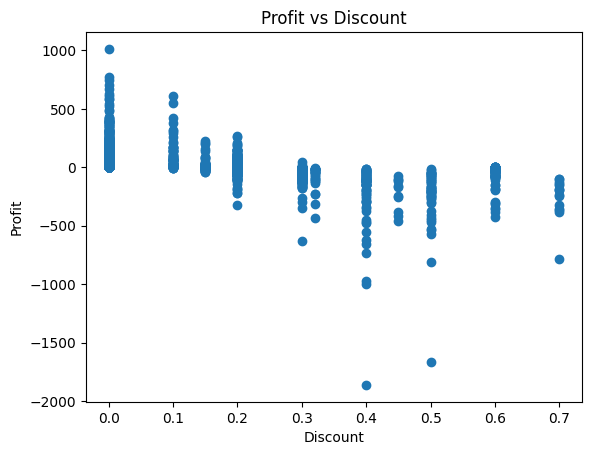

In [13]:
plt.scatter(df["Discount"], df["Profit"])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Profit vs Discount")
plt.show()

In [14]:
df.groupby(pd.cut(df["Discount"], bins=[0,0.2,0.4,0.6,0.8]))["Profit"].mean()


C:\Users\zezorn\AppData\Local\Temp\ipykernel_27908\2699663686.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["Discount"], bins=[0,0.2,0.4,0.6,0.8]))["Profit"].mean()


Discount
(0.0, 0.2]     19.913799
(0.2, 0.4]    -90.351393
(0.4, 0.6]   -104.970272
(0.6, 0.8]   -259.662627
Name: Profit, dtype: float64

In [15]:
df.to_csv("../data/processed/stores_sales_cleaned.csv", index=False)

### Results:
Company should retain a discount cap of < 20% to increase profitability, everything above rapidily increases losses.